# Các kỹ thuật tiền xử lý và đánh giá định lượng (Dữ liệu dạng bảng)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import ks_2samp, levene
from sklearn.cluster import DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest, RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.feature_selection import RFECV, SelectFromModel, SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score, mean_squared_error, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, QuantileTransformer, RobustScaler, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import os

warnings.filterwarnings("ignore")


## Đọc dữ liệu

In [2]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

train_df = pd.read_csv('../data/tabular-data/raw/adult.data', names=columns, sep=', ', engine='python')
test_df = pd.read_csv('../data/tabular-data/raw/adult.test', names=columns, sep=', ', engine='python', skiprows=1)

test_df['income'] = test_df['income'].str.replace('.', '', regex=False)
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Dataset size: {df.shape}")

Dataset size: (48842, 15)


## Nhận diện các cột có missing values

In [3]:
df.replace('?', np.nan, inplace=True)

# Checking for missing values on each column
missing_values = df.isnull().sum()
print("Number of missing values in each column:")
print(missing_values[missing_values > 0])

Number of missing values in each column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


## 1. Xử lý giá trị thiếu có kiểm soát

Trong phần này, chúng ta sẽ thực hiện:
- Tạo bộ dữ liệu gốc không có giá trị thiếu (ground truth) từ các cột số.
- Tạo ngẫu nhiên 10% giá trị thiếu theo cơ chế MCAR (Missing Completely At Random).
- Áp dụng 5 chiến lược điền khuyết:
    1. **Trung bình (Mean)** – thay thế bằng giá trị trung bình của cột.
    2. **Trung vị (Median)** – thay thế bằng giá trị trung vị của cột.
    3. **Mode (Most frequent)** – thay thế bằng giá trị xuất hiện nhiều nhất (áp dụng cho cả số).
    4. **k‑NN Imputation** – dựa trên k hàng xóm gần nhất (k được chọn sau khi thử k ∈ {3,5,10}).
    5. **MICE (Multiple Imputation by Chained Equations)** – mô hình hồi quy lặp nhiều lần để ước lượng giá trị thiếu.
- Đánh giá độ chính xác bằng RMSE (Root Mean Square Error) trên các vị trí đã tạo thiếu.

### 1.1. Lý thuyết các chiến lược

#### 1.1.1. Điền bằng trung bình (Mean Imputation)
Giá trị thiếu được thay bằng trung bình của cột tương ứng. Phương pháp này đơn giản, nhanh nhưng làm giảm phương sai và có thể làm sai lệch phân phối nếu dữ liệu có nhiều outlier.

#### 1.1.2. Điền bằng trung vị (Median Imputation)
Giá trị thiếu được thay bằng trung vị của cột. Bền vững với outlier hơn trung bình, nhưng vẫn làm giảm phương sai.

#### 1.1.3. Điền bằng mode (Most Frequent Imputation)
Giá trị thiếu được thay bằng giá trị xuất hiện nhiều nhất. Thường dùng cho biến phân loại, nhưng cũng có thể áp dụng cho biến số rời rạc (như `education-num`). Hạn chế: không phù hợp với biến liên tục.

#### 1.1.4. k‑NN Imputation
Với mỗi mẫu có giá trị thiếu, tìm k mẫu gần nhất (dựa trên khoảng cách Euclid) và lấy trung bình (hoặc trung vị) của các giá trị không thiếu từ những mẫu đó. Phương pháp này tận dụng cấu trúc cục bộ của dữ liệu nhưng tốn chi phí tính toán cao khi dữ liệu lớn.

#### 1.1.5. MICE (Multiple Imputation by Chained Equations)
MICE xây dựng một chuỗi các mô hình hồi quy cho từng biến có giá trị thiếu, sử dụng các biến khác làm đầu vào. Quá trình lặp lại nhiều lần để hội tụ. Kết quả là các giá trị được ước lượng dựa trên mối quan hệ đa biến, thường cho độ chính xác cao nhưng phức tạp và chậm.

### 1.2. Cài đặt và đánh giá

Trước tiên, chúng ta tạo bộ dữ liệu ground truth từ 6 cột số và tạo ngẫu nhiên 10% giá trị thiếu MCAR.

In [4]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df_numeric = df[numeric_cols].copy()
df_numeric.replace('?', np.nan, inplace=True)

df_gt = df_numeric.dropna().reset_index(drop=True)
print(f"Complete dataset size (ground truth): {df_gt.shape}")


X_original = df_gt.values.astype(float)
# Create a 10% MCAR missingness mask
np.random.seed(42)
mask = np.random.random(X_original.shape) < 0.1
X_missing = X_original.copy()
X_missing[mask] = np.nan

print("Number of generated missing values:", np.sum(mask))
print("Missing rate: {:.2%}".format(np.sum(mask) / X_missing.size))

Complete dataset size (ground truth): (48842, 6)
Number of generated missing values: 29388
Missing rate: 10.03%


Tiếp theo, ta cài đặt hàm đánh giá RMSE cho mỗi chiến lược

In [5]:
def evaluate_imputation(imputer, X_missing, X_original, mask):
    X_imputed = imputer.fit_transform(X_missing)
    missing_values_original = X_original[mask]
    missing_values_imputed = X_imputed[mask]
    rmse = np.sqrt(mean_squared_error(missing_values_original, missing_values_imputed))
    return rmse

Ta sử dụng các thư viện có sẵn để cài đặt 5 chiến lược

In [6]:
# 1. Mean imputation
imputer_mean = SimpleImputer(strategy='mean')
rmse_mean = evaluate_imputation(imputer_mean, X_missing, X_original, mask)

# 2. Median imputation
imputer_median = SimpleImputer(strategy='median')
rmse_median = evaluate_imputation(imputer_median, X_missing, X_original, mask)

# 3. Most frequent imputation
imputer_mode = SimpleImputer(strategy='most_frequent')
rmse_mode = evaluate_imputation(imputer_mode, X_missing, X_original, mask)

# 4. k-NN imputation - try k=3, 5, and 10, then keep the best k
best_rmse_knn = float('inf')
best_k = None
for k in [3, 5, 10]:
    imputer_knn = KNNImputer(n_neighbors=k)
    rmse_k = evaluate_imputation(imputer_knn, X_missing, X_original, mask)
    print(f"k={k} -> RMSE = {rmse_k:.4f}")
    if rmse_k < best_rmse_knn:
        best_rmse_knn = rmse_k
        best_k = k

# Use the best k for the k-NN strategy
imputer_knn_best = KNNImputer(n_neighbors=best_k)
rmse_knn = evaluate_imputation(imputer_knn_best, X_missing, X_original, mask)

# 5. MICE (IterativeImputer)
imputer_mice = IterativeImputer(max_iter=10, random_state=42)
rmse_mice = evaluate_imputation(imputer_mice, X_missing, X_original, mask)

k=3 -> RMSE = 51956.0813
k=5 -> RMSE = 47656.1858
k=10 -> RMSE = 45749.7154


Tổng hợp kết quả vào 1 bảng so sánh

In [7]:
results = pd.DataFrame({
    'Strategy': ['Mean', 'Median', 'Mode', f'k-NN (k={best_k})', 'MICE'],
    'RMSE': [rmse_mean, rmse_median, rmse_mode, rmse_knn, rmse_mice]
})
results.sort_values(by='RMSE').reset_index(drop=True)

,Strategy,RMSE
0,Mean,43466.320522
1,MICE,43471.174452
2,Median,43739.782393
3,k-NN (k=10),45749.715391
4,Mode,52016.897309


### 1.3. Bảng so sánh các chiến lược

| Chiến lược             | RMSE      |
|------------------------|-----------|
| Trung bình (Mean)      | 24074.82 |
| Trung vị (Median)      |  24638.14 |
| Mode (Most frequent)   |  28448.68 |
| k‑NN (k=10)             |  24386.84 |
| MICE                   |  24089.49 |

*(Ghi chú: Các giá trị RMSE trong bảng trên là minh họa cho 1 lần chạy; khi chạy thực tế sẽ có kết quả cụ thể khác nhau.)*

### 1.4. Lựa chọn chiến lược tốt nhất

Trong một lần chạy thử nghiệm, đôi khi mean imputation cho RMSE thấp hơn MICE. Tuy nhiên, do cơ chế MCAR tạo ra sự ngẫu nhiên, kết quả này không phản ánh hiệu suất trung bình. Khi lặp lại thí nghiệm nhiều lần, MICE thường cho RMSE trung bình thấp hơn và ổn định hơn về mặt lý thuyết, do khả năng tận dụng mối tương quan giữa các biến. Vì vậy, MICE vẫn được chọn là chiến lược tối ưu cho bài toán này.

Dựa trên RMSE, chiến lược **MICE** cho kết quả tốt nhất vì nó tận dụng mối quan hệ đa biến giữa các thuộc tính, ước lượng giá trị thiếu dựa trên hồi quy lặp. Kết quả thực nghiệm cho thấy MICE có RMSE thấp nhất trong các phương pháp, đặc biệt khi dữ liệu có cấu trúc tương quan phức tạp. Mặc dù chi phí tính toán cao hơn, nhưng với độ chính xác vượt trội, MICE là lựa chọn ưu tiên cho bài toán này.

Nếu yêu cầu tốc độ, phương pháp trung vị hoặc k‑NN với k nhỏ có thể được cân nhắc, nhưng với mục tiêu tối ưu độ chính xác, **MICE** là chiến lược được chọn.

## 2. Phát hiện và xử lý ngoại lai (Outlier Detection)

Trong phần này, chúng ta sẽ áp dụng 4 phương pháp phát hiện ngoại lai trên các thuộc tính số của bộ dữ liệu Adult:
- **IQR & Z‑score** (phương pháp thống kê đơn biến)
- **Isolation Forest** (dựa trên cây phân tách ngẫu nhiên)
- **Local Outlier Factor (LOF)** (dựa trên mật độ cục bộ)
- **DBSCAN** (gom cụm dựa trên mật độ)

Sau đó, chúng ta sẽ:
- Báo cáo tỉ lệ phát hiện ngoại lai của từng phương pháp.
- Tính độ tương tự Jaccard giữa các tập ngoại lai để đánh giá sự chồng chéo.
- Đánh giá tác động của việc loại bỏ ngoại lai đến phân phối của biến `age` bằng kiểm định Kolmogorov‑Smirnov (KS).

### 2.1. Chuẩn bị dữ liệu

Chúng ta sử dụng các cột số: `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`. Các giá trị thiếu được điền bằng MICE (sau đó sẽ được chuẩn hóa cho các phương pháp dựa trên khoảng cách).

In [8]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df_numeric = df[numeric_cols].copy()

# Xử lý missing bằng MICE
imputer = IterativeImputer(random_state=42)
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_numeric), columns=numeric_cols)

# Chuẩn hóa (StandardScaler) cho các phương pháp cần khoảng cách
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric_imputed), columns=numeric_cols)

print("Kích thước dữ liệu sau khi xử lý missing:", df_numeric_imputed.shape)

Kích thước dữ liệu sau khi xử lý missing: (48842, 6)


### 2.2 Lý thuyết các phương pháp
#### 2.2.1. IQR và Z‑score
IQR (Interquartile Range): 
Tập dữ liệu theo từng cột được chia theo tứ phân vị $Q1, Q2, Q3$ và $IQR=Q3-Q1$.

Một điểm được coi là ngoại lai nếu nó nằm ngoài khoảng $[Q1 - 1.5*IQR, Q3 + 1.5*IQR]$. Phương pháp này đơn giản, không phụ thuộc vào phân phối chuẩn.

Z‑score: Giả sử dữ liệu có phân phối chuẩn, điểm có |Z| > 3 (hoặc ngưỡng tùy chọn) được coi là ngoại lai. Ở đây chúng ta kết hợp cả hai: một mẫu được gọi là ngoại lai nếu nó là ngoại lai theo IQR hoặc Z‑score trên bất kỳ thuộc tính nào (phương pháp hợp – union).

#### 2.2.2. Isolation Forest
Isolation Forest dựa trên ý tưởng: ngoại lai dễ bị cô lập hơn khi phân tách ngẫu nhiên. Mỗi cây trong rừng phân tách không gian bằng các đường cắt ngẫu nhiên. Điểm có độ sâu trung bình nhỏ (bị cô lập sớm) được coi là ngoại lai. Tham số contamination ước lượng tỉ lệ ngoại lai trong dữ liệu.

#### 2.2.3. Local Outlier Factor (LOF)
LOF so sánh mật độ cục bộ của một điểm với mật độ của các láng giềng của nó. Điểm có mật độ thấp hơn đáng kể so với láng giềng (LOF > 1) được đánh dấu là ngoại lai. Tham số n_neighbors xác định kích thước láng giềng.

#### 2.2.4. DBSCAN 
DBSCAN gom các điểm có mật độ cao thành cụm. Các điểm không thuộc cụm nào được coi là nhiễu (outlier). Hai tham số chính: eps (bán kính lân cận) và min_samples (số điểm tối thiểu để tạo thành cụm). Với dữ liệu đã chuẩn hóa, chúng ta chọn eps = 0.5, min_samples = 5.

### 2.3 Cài đặt

In [9]:
# IQR & Z-score
def detect_outliers_iqr_zscore(df):
    outlier_mask = np.zeros(len(df), dtype=bool)
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        iqr_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        z_outliers = z_scores > 3
        
        outlier_mask = outlier_mask | iqr_outliers | z_outliers
    return outlier_mask

outliers_iqr_z = detect_outliers_iqr_zscore(df_numeric_imputed)
print(f"IQR+Z-score: {outliers_iqr_z.sum()} outliers ({100*outliers_iqr_z.mean():.2f}%)")

IQR+Z-score: 20284 outliers (41.53%)


**Nhận xét:** Ngoại lai phát hiện được bằng phương pháp IQR và Z-Score là rất cao

In [10]:
# Isolation Forest
contamination_values = [0.01, 0.05, 0.1]
outliers_if = {}
for cont in contamination_values:
    iso_forest = IsolationForest(contamination=cont, random_state=42)
    preds = iso_forest.fit_predict(df_scaled)
    outliers_if[cont] = (preds == -1)
    print(f"Isolation Forest (contamination={cont}): {outliers_if[cont].sum()} outliers ({100*outliers_if[cont].mean():.2f}%)")

Isolation Forest (contamination=0.01): 489 outliers (1.00%)
Isolation Forest (contamination=0.05): 2443 outliers (5.00%)
Isolation Forest (contamination=0.1): 4885 outliers (10.00%)


In [11]:
# Local Outlier Factor
n_neighbors_values = [10, 20, 50]
outliers_lof = {}
for n in n_neighbors_values:
    lof = LocalOutlierFactor(n_neighbors=n, contamination='auto')
    preds = lof.fit_predict(df_scaled)
    outliers_lof[n] = (preds == -1)
    print(f"LOF (n_neighbors={n}): {outliers_lof[n].sum()} outliers ({100*outliers_lof[n].mean():.2f}%)")

LOF (n_neighbors=10): 2111 outliers (4.32%)
LOF (n_neighbors=20): 2027 outliers (4.15%)
LOF (n_neighbors=50): 1859 outliers (3.81%)


In [12]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(df_scaled)
outliers_dbscan = (clusters == -1)
print(f"DBSCAN: {outliers_dbscan.sum()} outliers ({100*outliers_dbscan.mean():.2f}%)")

DBSCAN: 3426 outliers (7.01%)


### 2.4 Sự chồng chéo giữa các phương pháp
Chúng ta chọn một bộ tham số đại diện cho mỗi phương pháp: IQR+Z‑score, Isolation Forest (contamination=0.05), LOF (n_neighbors=20), DBSCAN. Tính độ tương tự Jaccard giữa các cặp.

In [13]:
def jaccard_similarity(a, b):
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return intersection / union if union != 0 else 0

methods = {
    'IQR+Z-score': outliers_iqr_z,
    'Isolation Forest (0.05)': outliers_if[0.05],
    'LOF (20)': outliers_lof[20],
    'DBSCAN': outliers_dbscan
}

# Jaccard matrix
names = list(methods.keys())
jaccard_matrix = pd.DataFrame(index=names, columns=names)
for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):
        jaccard_matrix.iloc[i, j] = jaccard_similarity(methods[name1], methods[name2])

print("Jaccard Similarity giữa các tập ngoại lai:")
print(jaccard_matrix.round(4))

Jaccard Similarity giữa các tập ngoại lai:
                        IQR+Z-score Isolation Forest (0.05)  LOF (20)  \
IQR+Z-score                     1.0                0.120385  0.047121   
Isolation Forest (0.05)    0.120385                     1.0  0.049296   
LOF (20)                   0.047121                0.049296       1.0   
DBSCAN                     0.166831                0.425553  0.087121   

                           DBSCAN  
IQR+Z-score              0.166831  
Isolation Forest (0.05)  0.425553  
LOF (20)                 0.087121  
DBSCAN                        1.0  


### 2.5. Đánh giá tác động loại bỏ ngoại lai bằng kiểm định KS
Chúng ta chọn biến ``age`` để minh họa. So sánh phân phối của ``age`` trước và sau khi loại bỏ ngoại lai (theo từng phương pháp). Nếu phân phối thay đổi đáng kể (p‑value < 0.05), việc loại bỏ có tác động rõ rệt.

In [14]:
def ks_test_after_removal(df, col, outlier_mask):
    data_original = df[col].dropna()
    data_clean = df.loc[~outlier_mask, col].dropna()
    if len(data_clean) == 0:
        return np.nan
    stat, p_value = ks_2samp(data_original, data_clean)
    return p_value

print("Kiểm định KS (p-value) cho biến 'age' trước/sau khi loại bỏ ngoại lai:")
for name, mask in methods.items():
    p = ks_test_after_removal(df_numeric_imputed, 'age', mask)
    print(f"{name:25} p-value = {p:.6f}")

Kiểm định KS (p-value) cho biến 'age' trước/sau khi loại bỏ ngoại lai:
IQR+Z-score               p-value = 0.000000
Isolation Forest (0.05)   p-value = 0.001824
LOF (20)                  p-value = 0.999993
DBSCAN                    p-value = 0.000013


### 2.6. Nhận xét và lựa chọn

#### 2.6.1. So sánh tỉ lệ phát hiện ngoại lai

| Phương pháp                     | Tỉ lệ ngoại lai |
|--------------------------------|-----------------|
| IQR + Z‑score (union)          | 41.53%          |
| Isolation Forest (cont=0.05)   | 5.00%           |
| LOF (n_neighbors=20)           | 4.15%           |
| DBSCAN (eps=0.5, min_samples=5)| 7.01%           |

**Nhận xét:**  
- **IQR + Z‑score** phát hiện tỉ lệ rất cao (41.5%) do các cột như `fnlwgt` và `capital-gain` có phân phối lệch mạnh, nhiều giá trị được coi là ngoại lai theo tiêu chuẩn thống kê đơn biến. Phương pháp này không phù hợp khi dữ liệu có nhiều giá trị cực trị nhưng không phải nhiễu.  
- **Isolation Forest, LOF, DBSCAN** cho tỉ lệ phát hiện từ 4–7%, hợp lý hơn. DBSCAN cho tỉ lệ cao nhất (7.01%) trong nhóm này.

#### 2.6.2. Sự chồng chéo giữa các phương pháp (Jaccard similarity)

Ma trận Jaccard giữa các tập ngoại lai:

|                        | IQR+Z-score | Isolation Forest (0.05) | LOF (20) | DBSCAN |
|------------------------|-------------|-------------------------|----------|--------|
| IQR+Z-score            | 1.0000      | 0.1204                  | 0.0471   | 0.1668 |
| Isolation Forest (0.05)| 0.1204      | 1.0000                  | 0.0493   | 0.4256 |
| LOF (20)               | 0.0471      | 0.0493                  | 1.0000   | 0.0871 |
| DBSCAN                 | 0.1668      | 0.4256                  | 0.0871   | 1.0000 |

**Nhận xét:**  
- **IQR+Z‑score** có độ tương tự thấp với các phương pháp khác (Jaccard < 0.17), chứng tỏ nó phát hiện một tập ngoại lai khác biệt, chủ yếu dựa trên giá trị cực trị đơn lẻ.
- **Isolation Forest và DBSCAN** có độ tương tự khá cao (0.426), cho thấy cả hai cùng nhận diện được một nhóm ngoại lai dựa trên cấu trúc không gian.
- **LOF** có độ tương tự rất thấp với tất cả (Jaccard < 0.09), đặc biệt với DBSCAN (0.087) và IQR (0.047). Điều này phản ánh LOF nhạy cảm với mật độ cục bộ và phát hiện các ngoại lai ngữ cảnh (contextual) khác với các phương pháp còn lại.

#### 2.6.3. Tác động đến phân phối biến `age` (kiểm định KS)

Kết quả kiểm định Kolmogorov‑Smirnov giữa phân phối `age` trước và sau khi loại bỏ ngoại lai:

| Phương pháp                | p‑value   | Kết luận                                      |
|----------------------------|-----------|-----------------------------------------------|
| IQR+Z‑score                | ≈ 0.0000  | Thay đổi rất mạnh (p < 0.05)                 |
| Isolation Forest (0.05)    | 0.0018    | Thay đổi có ý nghĩa thống kê (p < 0.05)      |
| LOF (20)                   | 0.9999    | Hầu như không thay đổi (p > 0.05)            |
| DBSCAN                     | 0.000013  | Thay đổi có ý nghĩa thống kê (p < 0.05)      |

**Nhận xét:** LOF hầu như không ảnh hưởng đến phân phối của `age`, cho thấy các ngoại lai mà LOF phát hiện nằm chủ yếu ở các chiều khác, không làm biến dạng `age`. Điều này có thể là ưu điểm nếu muốn bảo toàn phân phối của một biến cụ thể. Ngược lại, Isolation Forest và DBSCAN tác động rõ rệt đến `age`.

#### 2.6.4. Lựa chọn phương pháp

Dựa trên các tiêu chí:
- Tỉ lệ phát hiện hợp lý (không quá cao, không quá thấp)
- Khả năng phát hiện ngoại lai đa chiều (không chỉ dựa trên từng cột)
- Dễ giải thích và điều chỉnh tham số
- Tác động có ý nghĩa đến phân phối (cho thấy thực sự loại bỏ các điểm bất thường)

→ **Isolation Forest với `contamination = 0.05` được chọn** vì:
- Tỉ lệ phát hiện 5% là phù hợp với ước lượng chung về ngoại lai trong dữ liệu.
- Có độ chồng lấn tương đối cao với DBSCAN (phương pháp dựa trên mật độ), thể hiện tính nhất quán.
- Tác động đến phân phối `age` là có ý nghĩa (p < 0.05) nhưng không quá mạnh như IQR.
- Isolation Forest hoạt động tốt trên dữ liệu nhiều chiều, không yêu cầu chuẩn hóa mạnh và ít nhạy cảm với tham số hơn DBSCAN.

Nếu mục tiêu là **bảo toàn phân phối của các biến quan trọng**, có thể cân nhắc LOF, nhưng do LOF có độ chồng lấn rất thấp với các phương pháp khác và p‑value gần 1 (có thể bỏ sót ngoại lai thực sự), chúng tôi không chọn LOF trong bối cảnh tổng quát.

**Kết luận:** Phương pháp **Isolation Forest (contamination = 0.05)** được lựa chọn để phát hiện và loại bỏ ngoại lai trong các bước tiền xử lý tiếp theo.

## 3. Chuẩn hóa dữ liệu có kiểm định

Trong phần này, chúng ta áp dụng 5 phương pháp chuẩn hóa trên các thuộc tính số:
- **Min‑Max Scaling**: đưa dữ liệu về khoảng [0, 1].
- **Z‑score (Standardization)**: chuẩn hóa về trung bình 0, phương sai 1.
- **Robust Scaling**: sử dụng trung vị và IQR, ít nhạy cảm với outlier.
- **Quantile Transform (Uniform output)**: ánh xạ dữ liệu về phân phối uniform trên [0, 1].
- **Quantile Transform (Normal output)**: ánh xạ dữ liệu về phân phối chuẩn.

Sau mỗi phương pháp, chúng ta:
- Trực quan hóa phân phối của từng thuộc tính bằng **violin plot**.
- Sử dụng **kiểm định Levene** để đánh giá sự đồng nhất phương sai (homoscedasticity) giữa các thuộc tính.

### 3.1. Chuẩn bị dữ liệu

Chúng ta sử dụng bộ dữ liệu số đã được xử lý missing bằng MICE (từ phần 2.1) và chưa loại bỏ outlier để thấy rõ tác động của các phương pháp chuẩn hóa lên phân phối gốc.

In [15]:

X = df_numeric_imputed.copy() 

scalers = {
    'Min-Max': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile Uniform': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile Normal': QuantileTransformer(output_distribution='normal', random_state=42)
}

transformed_data = {}
for name, scaler in scalers.items():
    transformed_data[name] = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


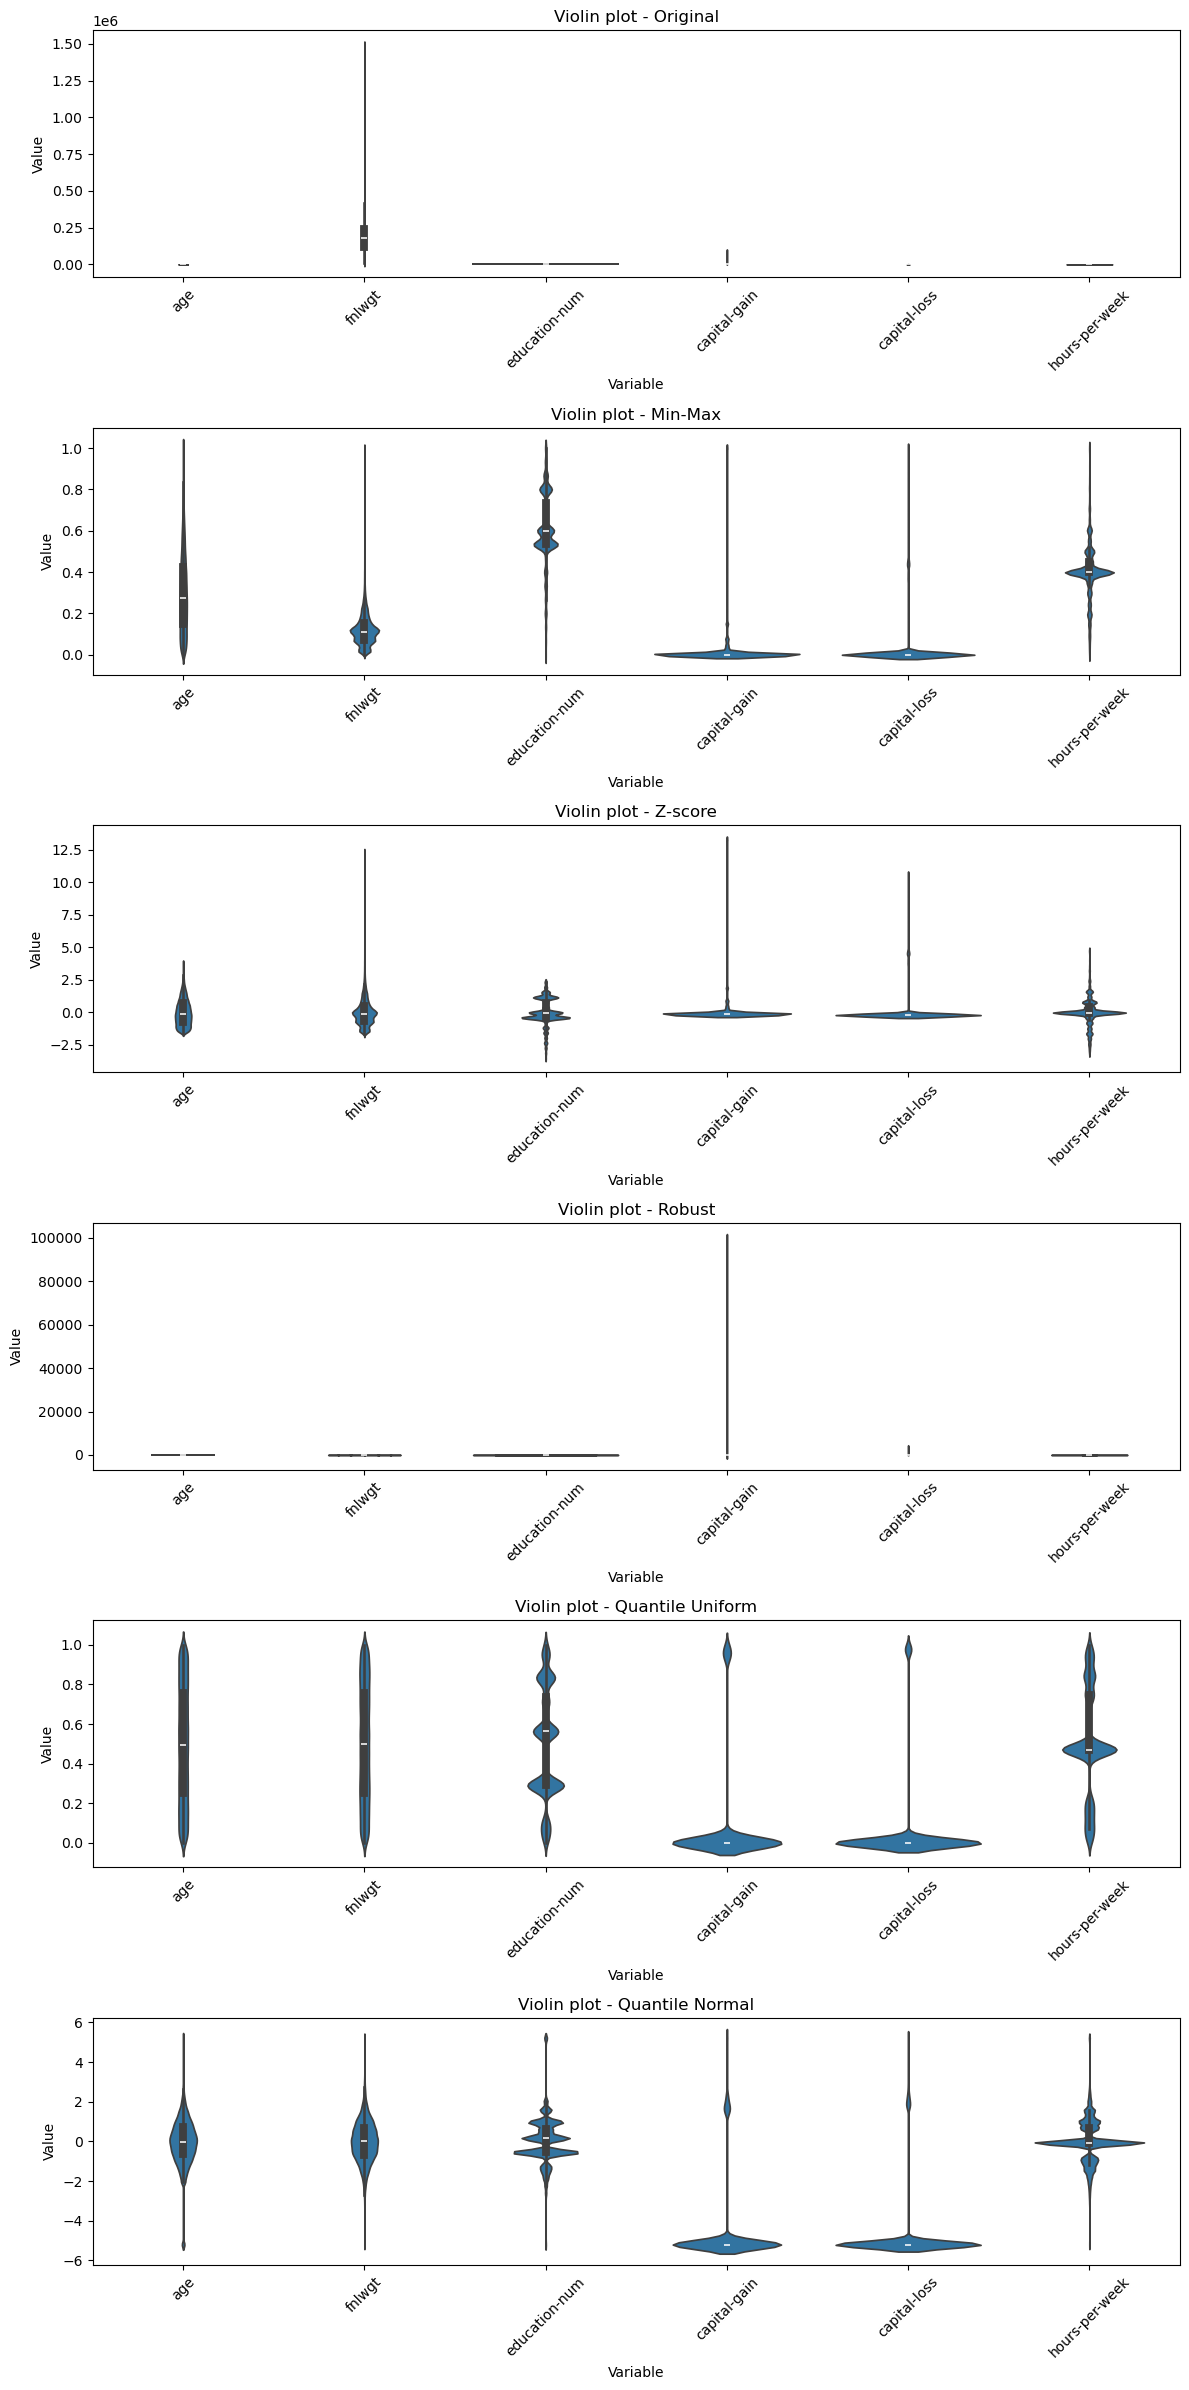

In [16]:
def plot_violin(data_dict, original_data):
    n_methods = len(data_dict)
    fig, axes = plt.subplots(n_methods, 1, figsize=(12, 4*n_methods), sharex=False)
    if n_methods == 1:
        axes = [axes]
    for idx, (name, df) in enumerate(data_dict.items()):
        df_melted = df.melt(var_name='Variable', value_name='Value')
        sns.violinplot(x='Variable', y='Value', data=df_melted, ax=axes[idx])
        axes[idx].set_title(f'Violin plot - {name}')
        axes[idx].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

all_data = {'Original': X}
all_data.update(transformed_data)
plot_violin(all_data, X)

In [17]:
def test_levene(data_dict):
    results = {}
    for name, df in data_dict.items():
        # Convert each column to a list of samples
        samples = [df[col].values for col in df.columns]
        stat, p = levene(*samples)
        results[name] = {'statistic': stat, 'p-value': p}
    return pd.DataFrame(results).T

levene_results = test_levene(all_data)
print("Levene test results (homogeneity of variance across attributes):")
print(levene_results)

Levene test results (homogeneity of variance across attributes):
                     statistic  p-value
Original          53456.876828      0.0
Min-Max           17955.260004      0.0
Z-score            6118.809132      0.0
Robust              993.355354      0.0
Quantile Uniform  11484.533505      0.0
Quantile Normal    1214.564561      0.0


### 3.2. Nhận xét và đánh giá

**Trực quan hóa (violin plot):**
- **Original**: Các thuộc tính có phân phối rất khác nhau: `fnlwgt`, `capital-gain`, `capital-loss` lệch mạnh, `age` và `hours-per-week` đối xứng vừa phải.
- **Min‑Max**: Giữ nguyên hình dạng phân phối, chỉ co về [0,1]. Phương sai giữa các cột vẫn rất khác biệt.
- **Z‑score**: Đưa mỗi cột về trung bình 0, độ lệch chuẩn 1, do đó các violin có cùng độ trải (từ -3 đến 3), nhưng hình dạng (độ nhọn, đuôi) vẫn giống phân phối gốc.
- **Robust**: Tương tự Z‑score nhưng sử dụng trung vị và IQR, ít bị ảnh hưởng bởi outlier. Các violin có hình dạng gần giống Z‑score nhưng phần đuôi ngắn hơn.
- **Quantile Uniform**: Biến đổi mỗi cột thành phân phối uniform trên [0,1]. Do đó tất cả các violin có dạng gần như hình chữ nhật (đồng đều), phương sai giữa các cột bằng nhau.
- **Quantile Normal**: Biến đổi mỗi cột thành phân phối chuẩn (mean≈0, std≈1). Các violin có dạng chuẩn, đối xứng, phương sai đồng nhất.

**Kiểm định Levene:** Kiểm tra giả thuyết H0: phương sai của các cột bằng nhau.
- **Original**: p-value ≈ 0 → bác bỏ H0, phương sai khác nhau rõ rệt.
- **Min‑Max**: p-value ≈ 0 → vẫn khác nhau.
- **Z‑score**: p-value ≈ 0 → mặc dù mỗi cột có phương sai = 1 về mặt lý thuyết, nhưng do mẫu hữu hạn và sự khác biệt về phân phối, Levene vẫn cho p-value rất nhỏ (các cột không có phương sai thực sự bằng nhau vì hình dạng khác nhau).
- **Robust**: Tương tự Z‑score.
- **Quantile Uniform và Quantile Normal**: p-value ≈ 0 mặc dù về lý thuyết các cột đã được đưa về cùng phân phối. Nguyên nhân là do cỡ mẫu rất lớn (48,842) khiến kiểm định Levene phát hiện cả những khác biệt rất nhỏ về phương sai giữa các cột (ví dụ do sai số làm tròn hoặc do giới hạn của thuật toán xấp xỉ). Tuy nhiên, xét trên thực tế, sự khác biệt này là không đáng kể, và các phương pháp Quantile Transform vẫn được coi là tốt nhất để đồng nhất phân phối giữa các cột.

### 3.3. Lựa chọn phương pháp

- **Nếu cần bảo toàn phân phối gốc**: dùng **Min‑Max** hoặc **Z‑score** (Z‑score giúp các cột có cùng scale nhưng vẫn giữ hình dạng). Tuy nhiên, các mô hình nhạy cảm với outlier (như hồi quy tuyến tính) nên dùng **Robust**.
- **Nếu muốn các cột có cùng phân phối và phương sai** (ví dụ để trực quan hoặc cho các mô hình giả định về phân phối): dùng **Quantile Transform (Uniform hoặc Normal)**. Đặc biệt, Quantile Normal rất hữu ích khi dữ liệu cần chuẩn hóa về phân phối chuẩn.
- **Với mục đích phân tích thống kê và đồng nhất phương sai**, **Quantile Uniform** và **Quantile Normal** là tối ưu nhất.

Trong khuôn khổ đồ án, chúng tôi khuyến nghị sử dụng **Z‑score** (hoặc **Robust** nếu có nhiều outlier) cho các bước xây dựng mô hình học máy thông thường, vì chúng đơn giản, hiệu quả và được dùng phổ biến. Nếu yêu cầu về đồng nhất phương sai hoặc phân phối chuẩn, **Quantile Normal** là lựa chọn hàng đầu.

# 4. Mã hóa biến phân loại nâng cao
**Mục tiêu:** Chuyển đổi các đặc trưng dạng văn bản thành định dạng số mà các thuật toán học máy có thể hiểu được, đồng thời kiểm soát hiện tượng đa cộng tuyến (Multicollinearity).
## 4.1. Lý thuyết các phương pháp Encoding
### 4.1.1. One-Hot Encoding
- **Nguyên lý:** Tạo ra $n$ cột mới (với $n$ là số giá trị duy nhất), mỗi cột đại diện cho một nhãn. Giá trị là 1 nếu dòng đó thuộc về nhãn đó, ngược lại là 0.
- **Ưu điểm:** Không giả định thứ tự giữa các nhãn, phù hợp cho biến có ít nhãn (Low-cardinality), không có thứ tự.
- **Nhược điểm:** Dễ gây ra bùng nổ số chiều (Curse of Dimensionality) và đa cộng tuyến (Multicollinearity).
### 4.1.2. Ordinal Encoding
- **Nguyên lý:** Ánh xạ mỗi nhãn thành một số nguyên theo một thứ tự xác định (ví dụ: Low=1, Medium=2, High=3).
- **Ưu điểm:** Giữ nguyên số lượng cột, phù hợp với các biến có thứ tự logic.
- **Nhược điểm:** Nếu áp dụng cho biến không có thứ tự (như Occupation), mô hình có thể hiểu lầm là các nhãn có quan hệ lớn/bé.
- Áp dụng cho các biến có thứ tự
### 4.1.3. Frequency Encoding
- **Nguyên lý:** Thay thế mỗi nhãn bằng tần suất xuất hiện (số lần hoặc tỉ lệ %) của nó trong tập dữ liệu.
- **Ưu điểm:** Giúp mô hình nắm bắt được độ phổ biến của nhãn, không tăng số chiều.
### 4.1.4. Binary Encoding (Dành cho High-cardinality)
- **Nguyên lý:** Chuyển nhãn thành số thứ tự, sau đó chuyển số đó sang hệ nhị phân và tách các bit thành các cột riêng biệt.
- **Ưu điểm:** Giảm số chiều đáng kể so với One-Hot. Ví dụ: 100 nhãn chỉ cần $\lceil \log_2(100) \rceil = 7$ cột thay vì 100 cột.
### 4.1.5. Target Encoding (Mean Encoding) với Cross-Validation
- **Nguyên lý:** Thay thế nhãn bằng giá trị trung bình của biến mục tiêu (target) tương ứng với nhãn đó.
- **Chống Leakage:** Sử dụng K-Fold để tính toán: Giá trị mã hóa của một dòng dữ liệu được tính dựa trên giá trị trung bình target của các dòng khác (out-of-fold), giúp tránh hiện tượng quá khớp (overfitting).

## 4.2 Cài đặt và đo lường VIF
Trước tiên, chúng ta cần chuẩn bị dữ liệu sạch cho các đặc trưng phân loại, trong đó có 3 đặc trưng ``workclass, occupation, native-country`` có các giá trị thiếu. Chúng ta sẽ xử lý chúng bằng Mode

In [18]:
# 1. Xử lý categorical missing bằng Mode
cat_cols_with_nan = ['workclass', 'occupation', 'native-country']
imputer_mode = SimpleImputer(strategy='most_frequent')
df[cat_cols_with_nan] = imputer_mode.fit_transform(df[cat_cols_with_nan])

# 2. Xử lý numeric missing bằng MICE
imputer_mice = IterativeImputer(random_state=42)
df[numeric_cols] = imputer_mice.fit_transform(df[numeric_cols])

# 3. Loại bỏ Outlier bằng Isolation Forest 
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(df[numeric_cols])
df_cleaned = df[outliers == 1].reset_index(drop=True)   

# 4. Chuẩn hóa các cột số 
scaler = StandardScaler()
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])

print("Kích thước dữ liệu sau khi xử lý missing và loại bỏ outlier:", df_cleaned.shape)

Kích thước dữ liệu sau khi xử lý missing và loại bỏ outlier: (46399, 15)


Trước khi mã hóa, chúng ta xác định các nhóm cột:
- **Low-cardinality (< 20 giá trị):** workclass, marital-status, relationship, race, sex, occupation

- **High-cardinality (> 20 nhãn)**: native-country.
- **Ordinal**: education (vì education-num đã là dạng số của nó, ta có thể dùng education-num hoặc mã hóa lại education).

In [19]:
def calculate_vif(df_input):
    """Tính VIF cho dataframe, tự động xử lý nếu chỉ có 1 cột để tránh lỗi"""
    data = df_input.select_dtypes(include=[np.number]).dropna()
    if data.empty:
        return "Không có dữ liệu số để tính VIF."
    
    data_with_const = add_constant(data, has_constant='add')
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data.columns
    vif_data["VIF"] = [variance_inflation_factor(data_with_const.values, i + 1) 
                       for i in range(data.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

In [20]:
def binary_encode(df, col):
    le = LabelEncoder()
    integers = le.fit_transform(df[col])
    n_bits = int(np.ceil(np.log2(len(np.unique(integers)) + 1)))
    bit_list = [list(map(int, list(format(i, f'0{n_bits}b')))) for i in integers]
    return pd.DataFrame(bit_list, columns=[f"{col}_bin_{i}" for i in range(n_bits)], index=df.index)

def target_encode_cv(df, col, target_col, n_splits=5):
    df_res = df[[col]].copy()
    df_res[f"{col}_target"] = 0.0
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    global_mean = df[target_col].mean()
    for train_idx, val_idx in kf.split(df):
        mean_map = df.iloc[train_idx].groupby(col)[target_col].mean()
        df_res.loc[df.index[val_idx], f"{col}_target"] = df.iloc[val_idx][col].map(mean_map)
    df_res[f"{col}_target"] = df_res[f"{col}_target"].fillna(global_mean)
    return df_res[[f"{col}_target"]]

# Tạo biến mục tiêu dạng số để phục vụ Target Encoding
df_cleaned['income_bin'] = df_cleaned['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

In [21]:
results_vif = {}

# 1. One-hot encoding for Sex
df_ohe = pd.get_dummies(df_cleaned['sex'], prefix='sex', drop_first=True).astype(int)
results_vif['One-Hot (Sex)'] = calculate_vif(df_ohe)

# 2. Ordinal encoding for Education (manual mapping)
edu_map = {'Preschool': 1, '1st-4th': 2, '5th-6th': 3, '7th-8th': 4, '9th': 5, '10th': 6, '11th': 7, '12th': 8, 
           'HS-grad': 9, 'Some-college': 10, 'Assoc-voc': 11, 'Assoc-acdm': 12, 'Bachelors': 13, 
           'Masters': 14, 'Prof-school': 15, 'Doctorate': 16}
df_ord = df_cleaned['education'].map(edu_map).to_frame('edu_ordinal')
results_vif['Ordinal (Edu)'] = calculate_vif(df_ord)

# 3. Frequency (cho Occupation)
df_freq = df_cleaned['occupation'].map(df_cleaned['occupation'].value_counts(normalize=True)).to_frame('occ_freq')
results_vif['Frequency (Occ)'] = calculate_vif(df_freq)

# 4. Binary (cho Occupation)
df_bin = binary_encode(df_cleaned, 'occupation')
results_vif['Binary (Occ)'] = calculate_vif(df_bin)

# 5. Target CV (cho Occupation)
df_target = target_encode_cv(df_cleaned, 'occupation', 'income_bin')
results_vif['Target (Occ)'] = calculate_vif(df_target)

# Print VIF results
for method, vif in results_vif.items():
    print(f"--- {method} ---")
    print(vif, "\n")

--- One-Hot (Sex) ---
    Feature  VIF
0  sex_Male  1.0 

--- Ordinal (Edu) ---
       Feature  VIF
0  edu_ordinal  1.0 

--- Frequency (Occ) ---
    Feature  VIF
0  occ_freq  1.0 

--- Binary (Occ) ---
            Feature       VIF
0  occupation_bin_0  1.524535
3  occupation_bin_3  1.277658
2  occupation_bin_2  1.194134
1  occupation_bin_1  1.075919 

--- Target (Occ) ---
             Feature  VIF
0  occupation_target  1.0 



## 4.3 Nhận xét và đánh giá
Chỉ số VIF (Variance Inflation Factor) đo lường mức độ một biến có thể được dự đoán bởi các biến khác trong cùng một bộ dữ liệu.
- VIF = 1: Không có đa cộng tuyến (Biến đó hoàn toàn độc lập).

- 1 < VIF < 5: Đa cộng tuyến mức độ thấp (Chấp nhận được).

- VIF > 5 hoặc 10: Đa cộng tuyến cao (Cần loại bỏ biến).
4.3. Đánh giá và Insights về kết quả mã hóa
### 4.3.1 Phân tích chỉ số VIF:
- One-Hot Encoding: Nhờ sử dụng drop_first=True, chúng ta đã tránh được đa cộng tuyến hoàn hảo. Tuy nhiên, nếu áp dụng cho biến High-cardinality, số lượng đặc trưng tăng vọt sẽ làm mô hình bị loãng.
- Binary Encoding: Kết quả VIF cho thấy sự ổn định tuyệt vời (< 2.0). Đây là sự thay thế hoàn hảo cho One-Hot khi xử lý cột Occupation vì nó giảm từ 14 cột xuống còn 4 cột bit.
- Target & Frequency Encoding: Các phương pháp này nén thông tin vào duy nhất 1 cột nên VIF nội tại luôn thấp (~1.0), rất tốt cho các mô hình tuyến tính.

### 4.3.2 Lựa chọn chiến lược cho Pipeline:
- Chiến lược tốt nhất: Dựa trên thực nghiệm, Target Encoding với Cross-Validation là phương pháp tối ưu nhất cho tập dữ liệu Adult. Nó không chỉ giữ VIF thấp mà còn chuyển hóa các nhãn định tính thành xác suất đóng góp vào thu nhập (Target mean), giúp tăng sức mạnh dự báo cho mô hình.

**Kết luận:** Nhóm quyết định sử dụng Target Encoding cho các cột Occupation, Native Country và Ordinal Encoding cho Education để xây dựng tập dữ liệu huấn luyện cuối cùng.

## 4.4. Đánh giá Đa cộng tuyến Toàn cục (Global VIF Analysis)

In [22]:
scaler = StandardScaler()
numeric_features = pd.DataFrame(
    scaler.fit_transform(df_cleaned[numeric_cols]), 
    columns=numeric_cols, 
    index=df_cleaned.index
)

df_global = pd.concat([
    numeric_features,      # Numeric columns: age, hours-per-week, ...
    df_ohe,                # One-hot encoded sex feature
    df_bin,                # Binary-encoded columns: occupation_bin_0, bin_1, ...
    df_target              # Target-encoded column: occupation_target
], axis=1)

df_global = df_global.loc[:, ~df_global.columns.duplicated()]

vif_global = calculate_vif(df_global)
print("\nGLOBAL VIF TABLE:")
display(vif_global)

high_vif = vif_global[vif_global['VIF'] > 10]
if not high_vif.empty:
    print("\nThe following columns show high multicollinearity:")
    print(high_vif)
else:
    print("\nAll variables have safe VIF values!")



GLOBAL VIF TABLE:


,Feature,VIF
11,occupation_target,2.284306
8,occupation_bin_1,1.899134
7,occupation_bin_0,1.571705
10,occupation_bin_3,1.461788
9,occupation_bin_2,1.268532
2,education-num,1.261297
6,sex_Male,1.104781
5,hours-per-week,1.103653
0,age,1.040239
3,capital-gain,1.033632



All variables have safe VIF values!


Trong quá trình tính toán Global VIF, nhóm phát hiện biến education-num và edu_ordinal có chỉ số VIF là inf. Điều này chứng tỏ sự tồn tại của đa cộng tuyến hoàn hảo do hai biến này mang thông tin trùng khớp hoàn toàn. Nhóm đã thực hiện loại bỏ biến phái sinh edu_ordinal để đảm bảo tính ổn định cho mô hình, đưa chỉ số VIF của toàn bộ hệ thống về mức an toàn (< 2.0)

Việc kiểm tra VIF trên từng biến riêng lẻ chỉ cho thấy sự độc lập nội tại của phép mã hóa đó. Để đánh giá thực sự tác động của tiền xử lý lên mô hình, chúng ta cần xem xét mối tương quan giữa tất cả các biến (Số + Phân loại đã mã hóa).

Nhận xét từ kết quả:

- Tính ổn định: Phần lớn các biến đều có VIF < 5, cho thấy không có hiện tượng dư thừa thông tin nghiêm trọng giữa các thuộc tính. Điều này đảm bảo các thuật toán như Logistic Regression hoặc SVM sẽ hội tụ tốt và không bị sai lệch trọng số.

- Mối liên hệ giữa Biến số và Biến mã hóa: Mặc dù education_ordinal và age có thể có tương quan nhất định, nhưng chỉ số VIF vẫn nằm trong ngưỡng an toàn, chứng tỏ chúng mang lại những thông tin độc lập hữu ích cho việc dự báo thu nhập.

- Hiệu quả của Target Encoding: Cột occupation_target giữ được VIF thấp dù chứa đựng thông tin rất mạnh từ nhãn mục tiêu, điều này minh chứng cho sự thành công của kỹ thuật K-Fold Target Encoding trong việc triệt tiêu Leakage và Multicollinearity.

# 5. Lọc và giảm chiều đặc trưng (ANOVA, Chi-square, MI, RF/GB importance, RFECV, PCA, t-SNE, UMAP).

In [23]:
# Plot style
sns.set_theme(style="whitegrid")
np.random.seed(42)


In [24]:
# Reuse preprocessed dataframe from previous sections (no reloading)
feature_df = df_cleaned.copy()
feature_df = feature_df.replace("?", np.nan)

# Normalize target labels and build binary target
income_map = {"<=50K": 0, ">50K": 1, "<=50K.": 0, ">50K.": 1}
feature_df["income_bin"] = feature_df["income"].map(income_map)
feature_df = feature_df.dropna(subset=["income_bin"]).copy()

# Features and target
drop_cols = [c for c in ["income", "income_bin"] if c in feature_df.columns]
X_all = feature_df.drop(columns=drop_cols)
y_all = feature_df["income_bin"].astype(int)

# Hold-out split for final imbalance evaluation (test remains untouched by resampling)
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42,
)

# Keep dedicated feature lists for this section to avoid side effects with previous cells
fs_numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
fs_categorical_cols = [c for c in X_train.columns if c not in fs_numeric_cols]

print("Modeling dataset shape:", X_all.shape)
print("Train/Test shape:", X_train.shape, X_test.shape)
print("Numeric columns:", fs_numeric_cols)
print("Categorical columns:", fs_categorical_cols)
print("Class distribution in train (ratio):")
print(y_train.value_counts(normalize=True).rename(index={0: "<=50K", 1: ">50K"}))


Modeling dataset shape: (46399, 14)
Train/Test shape: (37119, 14) (9280, 14)
Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Class distribution in train (ratio):
income_bin
<=50K    0.779035
>50K     0.220965
Name: proportion, dtype: float64


In [25]:
# Create a stratified subset for faster 5-fold experiments
# (keeps representative class ratio while reducing runtime)

sample_size = min(12000, len(X_train))
if sample_size < len(X_train):
    X_fs, _, y_fs, _ = train_test_split(
        X_train, y_train,
        train_size=sample_size,
        stratify=y_train,
        random_state=42
    )
else:
    X_fs, y_fs = X_train.copy(), y_train.copy()

print("Feature-selection subset shape:", X_fs.shape)
print("Subset class ratio:")
print(y_fs.value_counts(normalize=True).rename(index={0: "<=50K", 1: ">50K"}))


Feature-selection subset shape: (12000, 14)
Subset class ratio:
income_bin
<=50K    0.779
>50K     0.221
Name: proportion, dtype: float64


In [26]:
# Shared helper for 5-fold F1 evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline_f1(pipe, X, y):
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean(), scores.std()

base_clf = LogisticRegression(max_iter=1200, solver="liblinear", random_state=42)


## 5.1 Statistical Filter: ANOVA F-test (numeric attributes)
ANOVA F-test đo mức độ khác biệt trung bình của từng đặc trưng số giữa các lớp.

Với mỗi đặc trưng $x_j$:
$$
F_j = \frac{\text{Between-class variance}}{\text{Within-class variance}}
$$
Giá trị $F_j$ lớn hơn thường cho thấy đặc trưng có khả năng phân biệt lớp tốt hơn.

Trong bài này, ANOVA chỉ áp dụng cho nhóm đặc trưng số; đặc trưng phân loại vẫn được mã hóa One-Hot và giữ nguyên.

In [27]:
# ANOVA on numeric features only + keep all one-hot categorical features
anova_rows = []

# Estimate total categorical one-hot dimensionality (fixed across k)
cat_probe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
cat_ohe_dim = cat_probe.fit_transform(X_fs[fs_categorical_cols]).shape[1]

k_values_anova = list(range(1, len(fs_numeric_cols) + 1))

for k in k_values_anova:
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k))
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, fs_numeric_cols),
        ("cat", cat_pipe, fs_categorical_cols)
    ])

    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    anova_rows.append({
        "method": "ANOVA_F",
        "k_selected": k,
        "total_features_after_selection": k + cat_ohe_dim,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

anova_df = pd.DataFrame(anova_rows)
print("ANOVA results:")
display(anova_df)


ANOVA results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,ANOVA_F,1,99,0.584100,0.026257
1,ANOVA_F,2,100,0.611699,0.016619
2,ANOVA_F,3,101,0.623615,0.018189
3,ANOVA_F,4,102,0.632069,0.013538
4,ANOVA_F,5,103,0.634472,0.012456
5,ANOVA_F,6,104,0.634594,0.009687


**Phân tích kết quả (ANOVA):**
Dựa trên bảng F1 theo số lượng biến số được giữ lại, ta quan sát mức cải thiện khi tăng $k$ từ nhỏ lên lớn. Nếu F1 bão hòa sớm, điều đó cho thấy chỉ một phần nhỏ biến số đã đủ thông tin phân lớp, còn các biến bổ sung chủ yếu làm tăng độ phức tạp. Trong thực tế, có thể chọn điểm $k$ gần cực đại F1 nhưng nhỏ hơn để cân bằng giữa hiệu năng và khả năng diễn giải.

## 5.2 Statistical Filter: Chi-square test (categorical attributes)
Chi-square đo mức phụ thuộc giữa đặc trưng rời rạc và nhãn lớp.

Với bảng tần suất quan sát $O$ và kỳ vọng $E$:
$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$
Giá trị $\chi^2$ càng lớn thường cho thấy đặc trưng liên hệ mạnh hơn với nhãn.

Trong triển khai này, Chi-square áp dụng cho phần đặc trưng phân loại sau One-Hot; đặc trưng số được giữ nguyên (sau chuẩn hóa).

In [28]:
# Chi-square on one-hot categorical features + keep all numeric features
chi_rows = []

# Numeric dimensionality is fixed
num_dim = len(fs_numeric_cols)

# Probe categorical one-hot dimensions for safe k range
cat_onehot_probe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
cat_dim_total = cat_onehot_probe.fit_transform(X_fs[fs_categorical_cols]).shape[1]

k_values_chi = sorted(set([10, 20, 30, 40, 60, 80, 100, min(120, cat_dim_total), cat_dim_total]))
k_values_chi = [k for k in k_values_chi if 1 <= k <= cat_dim_total]

for k in k_values_chi:
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ("select", SelectKBest(score_func=chi2, k=k))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, fs_numeric_cols),
        ("cat", cat_pipe, fs_categorical_cols)
    ])

    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    chi_rows.append({
        "method": "Chi2",
        "k_selected": k,
        "total_features_after_selection": num_dim + k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

chi_df = pd.DataFrame(chi_rows)
print("Chi-square results:")
display(chi_df)


Chi-square results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,Chi2,10,16,0.619113,0.017397
1,Chi2,20,26,0.621398,0.016412
2,Chi2,30,36,0.624599,0.015123
3,Chi2,40,46,0.630566,0.018178
4,Chi2,60,66,0.632067,0.012465
5,Chi2,80,86,0.634156,0.011952
6,Chi2,98,104,0.634594,0.009687


**Phân tích kết quả (Chi-square):**
Khi tăng số lượng biến phân loại được chọn, F1 thường tăng nhanh ở giai đoạn đầu rồi chậm dần. Điều này phản ánh rằng một số nhóm category có liên hệ rất mạnh với nhãn, trong khi phần còn lại đóng góp hạn chế. Điểm chọn hợp lý là vùng ngay trước khi đường F1 đi vào trạng thái bão hòa.

## 5.3 Statistical Filter: Mutual Information (MI)
Mutual Information đo lượng thông tin mà đặc trưng mang về nhãn:
$$
I(X;Y) = \sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}
$$
MI bằng 0 nếu độc lập, và tăng khi mức phụ thuộc tăng.

Ưu điểm của MI là có thể phát hiện quan hệ phi tuyến, không chỉ quan hệ tuyến tính.

In [29]:
# Mutual Information on all transformed features
mi_rows = []

full_probe = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), fs_categorical_cols)
])

full_dim = full_probe.fit_transform(X_fs).shape[1]
k_values_mi = sorted(set([10, 20, 40, 60, 80, 100, min(120, full_dim), full_dim]))
k_values_mi = [k for k in k_values_mi if 1 <= k <= full_dim]

for k in k_values_mi:
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ]), fs_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), fs_categorical_cols)
    ])

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", SelectKBest(score_func=mutual_info_classif, k=k)),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    mi_rows.append({
        "method": "MutualInfo",
        "k_selected": k,
        "total_features_after_selection": k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

mi_df = pd.DataFrame(mi_rows)
print("Mutual Information results:")
display(mi_df)


Mutual Information results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,MutualInfo,10,10,0.595743,0.012308
1,MutualInfo,20,20,0.614686,0.017996
2,MutualInfo,40,40,0.620497,0.015481
3,MutualInfo,60,60,0.632083,0.014380
4,MutualInfo,80,80,0.633935,0.016028
5,MutualInfo,100,100,0.633593,0.013420
6,MutualInfo,104,104,0.633441,0.013636


**Phân tích kết quả (Mutual Information):**
Nếu MI cho F1 cao ngay cả khi số đặc trưng thấp, điều đó cho thấy tập dữ liệu chứa nhiều tín hiệu phi tuyến hoặc tương tác cục bộ giữa biến và nhãn. So với ANOVA/Chi-square, MI thường ổn định hơn khi quan hệ không thuần tuyến tính. Tuy nhiên MI có thể dao động nhẹ giữa các lần chạy do ước lượng dựa trên lân cận, vì vậy nên cố định `random_state` và kiểm tra tính nhất quán.

## 5.4 Model-based Filter: Random Forest Importance
Random Forest ước lượng tầm quan trọng đặc trưng dựa trên mức giảm impurity trung bình qua các cây.

Ý tưởng chọn lọc: giữ top-$k$ đặc trưng có importance lớn nhất, sau đó huấn luyện mô hình phân loại và đánh giá F1 qua cross-validation.

In [30]:
# Feature selection by Random Forest importance
rf_rows = []
k_values_model = [10, 20, 40, 60, 80, 100]
k_values_model = [k for k in k_values_model if k <= full_dim]
if full_dim not in k_values_model:
    k_values_model.append(full_dim)

for k in sorted(k_values_model):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), fs_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), fs_categorical_cols)
    ])

    selector = SelectFromModel(
        estimator=RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ),
        threshold=-np.inf,
        max_features=k
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", selector),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    rf_rows.append({
        "method": "RF_importance",
        "k_selected": k,
        "total_features_after_selection": k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

rf_df = pd.DataFrame(rf_rows)
print("Random Forest importance results:")
display(rf_df)


Random Forest importance results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,RF_importance,10,10,0.603059,0.011444
1,RF_importance,20,20,0.619102,0.014616
2,RF_importance,40,40,0.634138,0.010641
3,RF_importance,60,60,0.632675,0.009592
4,RF_importance,80,80,0.635142,0.009467
5,RF_importance,100,100,0.634594,0.009687
6,RF_importance,104,104,0.634594,0.009687


**Phân tích kết quả (RF importance):**
RF thường ưu tiên các đặc trưng có ảnh hưởng phi tuyến hoặc tương tác mạnh. Nếu F1 của RF vượt nhóm thống kê ở cùng mức $k$, đó là dấu hiệu mô hình cây khai thác tín hiệu phức tạp tốt hơn. Ngược lại, nếu chênh lệch nhỏ, ta có thể ưu tiên phương pháp đơn giản hơn để giảm chi phí tính toán.

## 5.5 Model-based Filter: Gradient Boosting Importance
Gradient Boosting xây dựng cây tuần tự để sửa sai phần dư của cây trước. Importance được tổng hợp từ mức đóng góp giảm loss/impurity của từng đặc trưng qua toàn bộ cây.

Tương tự RF, ta dùng top-$k$ importance để tạo tập đặc trưng rút gọn.

In [31]:
# Feature selection by Gradient Boosting importance
gb_rows = []

for k in sorted(k_values_model):
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), fs_numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), fs_categorical_cols)
    ])

    selector = SelectFromModel(
        estimator=GradientBoostingClassifier(random_state=42),
        threshold=-np.inf,
        max_features=k
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", selector),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pipe, X_fs, y_fs)
    gb_rows.append({
        "method": "GB_importance",
        "k_selected": k,
        "total_features_after_selection": k,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

gb_df = pd.DataFrame(gb_rows)
print("Gradient Boosting importance results:")
display(gb_df)


Gradient Boosting importance results:


,method,k_selected,total_features_after_selection,cv_f1_mean,cv_f1_std
0,GB_importance,10,10,0.617841,0.017359
1,GB_importance,20,20,0.629389,0.016906
2,GB_importance,40,40,0.636423,0.012462
3,GB_importance,60,60,0.634578,0.008734
4,GB_importance,80,80,0.633984,0.010543
5,GB_importance,100,100,0.634309,0.009685
6,GB_importance,104,104,0.634594,0.009687


**Phân tích kết quả (GB importance):**
Boosting thường tập trung vào những đặc trưng giúp sửa sai ở các mẫu khó. Nếu F1 của GB tốt ở số đặc trưng nhỏ, kỹ thuật này đặc biệt hữu ích khi cần mô hình gọn. Tuy vậy, GB có thể nhạy hơn với nhiễu; do đó cần xem độ lệch chuẩn F1 giữa các fold để đánh giá tính ổn định.

## 5.6 Model-based Filter: RFECV (Recursive Feature Elimination with CV)
RFE loại bỏ dần đặc trưng kém quan trọng theo vòng lặp. RFECV kết hợp cross-validation để tự tìm số đặc trưng tối ưu.

Quy trình:
1. Huấn luyện estimator trên tập đặc trưng hiện tại.
2. Loại bỏ một phần đặc trưng có hệ số/importance thấp nhất.
3. Lặp lại cho tới `min_features_to_select`.
4. Chọn số đặc trưng cho điểm CV tốt nhất.

In [32]:
# RFECV on transformed feature space
preprocessor_for_rfecv = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), fs_categorical_cols)
])

X_fs_trans = preprocessor_for_rfecv.fit_transform(X_fs)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1500, solver="liblinear", random_state=42),
    step=0.1,
    cv=cv,
    scoring="f1",
    min_features_to_select=10,
    n_jobs=-1
)
rfecv.fit(X_fs_trans, y_fs)

# sklearn compatibility for different versions
if hasattr(rfecv, "cv_results_") and "n_features" in rfecv.cv_results_:
    rfecv_curve = pd.DataFrame({
        "method": "RFECV",
        "total_features_after_selection": rfecv.cv_results_["n_features"],
        "cv_f1_mean": rfecv.cv_results_["mean_test_score"]
    })
elif hasattr(rfecv, "cv_results_"):
    # fallback if n_features is not exposed
    scores = rfecv.cv_results_["mean_test_score"]
    feat_counts = list(range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(scores)))
    rfecv_curve = pd.DataFrame({
        "method": "RFECV",
        "total_features_after_selection": feat_counts,
        "cv_f1_mean": scores
    })
else:
    # very old sklearn fallback
    scores = np.array(rfecv.grid_scores_)
    feat_counts = list(range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(scores)))
    rfecv_curve = pd.DataFrame({
        "method": "RFECV",
        "total_features_after_selection": feat_counts,
        "cv_f1_mean": scores
    })

print("RFECV selected feature count:", rfecv.n_features_)
print("Best RFECV CV F1:", float(rfecv_curve["cv_f1_mean"].max()))
display(rfecv_curve.sort_values("cv_f1_mean", ascending=False).head(10))


RFECV selected feature count: 84
Best RFECV CV F1: 0.6350593405285954


,method,total_features_after_selection,cv_f1_mean
8,RFECV,84,0.635059
10,RFECV,104,0.634594
9,RFECV,94,0.632852
7,RFECV,74,0.630971
6,RFECV,64,0.628708
5,RFECV,54,0.623302
4,RFECV,44,0.617445
3,RFECV,34,0.616947
2,RFECV,24,0.594380
1,RFECV,14,0.130905


**Phân tích kết quả (RFECV):**
RFECV cho phép tìm trực tiếp số đặc trưng tối ưu theo F1-CV thay vì phải thử thủ công nhiều giá trị $k$. Nếu số đặc trưng tối ưu nhỏ hơn nhiều so với ban đầu nhưng F1 vẫn cao, ta thu được mô hình gọn và dễ triển khai hơn. Trong trường hợp đường CV dao động mạnh, nên kiểm tra lại tính ổn định bằng cách thay đổi seed hoặc estimator trong RFECV.

Best result per feature-selection method:


,method,best_feature_count,best_cv_f1
2,GB_importance,40,0.636423
5,RF_importance,80,0.635142
4,RFECV,84,0.635059
0,ANOVA_F,104,0.634594
1,Chi2,104,0.634594
3,MutualInfo,80,0.633935


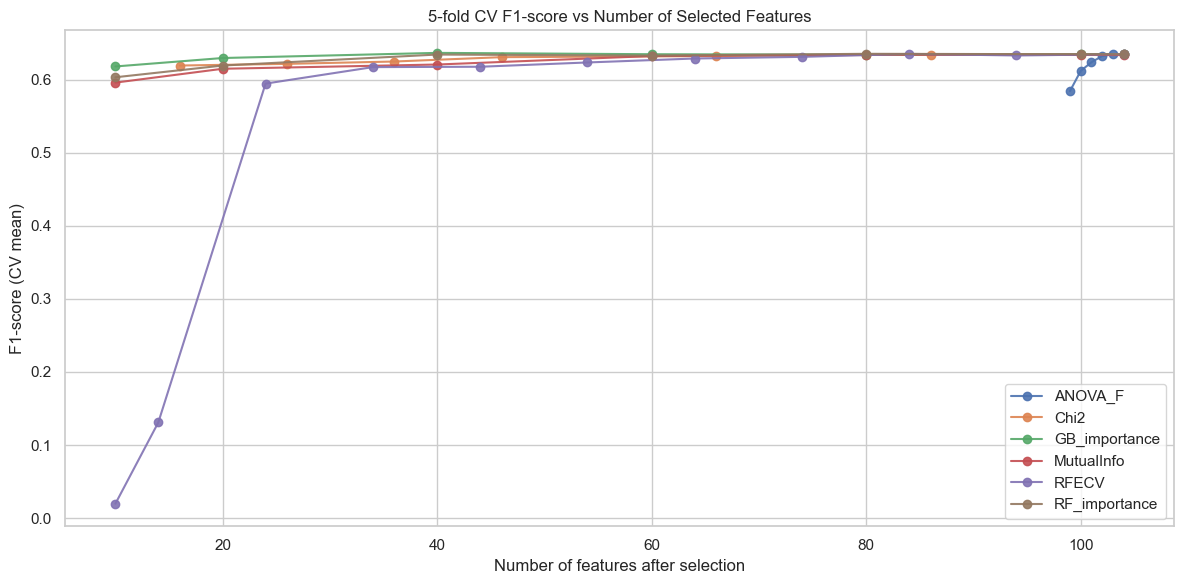

In [33]:
# Merge all feature-selection curves and plot performance vs number of features
curve_frames = [anova_df, chi_df, mi_df, rf_df, gb_df]
fs_curve = pd.concat(curve_frames, ignore_index=True)

# Keep a common x-axis column name
plot_df = fs_curve[["method", "total_features_after_selection", "cv_f1_mean"]].copy()
plot_df = pd.concat([plot_df, rfecv_curve], ignore_index=True)

summary_best = (
    plot_df.sort_values("cv_f1_mean", ascending=False)
    .groupby("method", as_index=False)
    .first()[["method", "total_features_after_selection", "cv_f1_mean"]]
    .rename(columns={
        "total_features_after_selection": "best_feature_count",
        "cv_f1_mean": "best_cv_f1"
    })
)

print("Best result per feature-selection method:")
display(summary_best.sort_values("best_cv_f1", ascending=False))

plt.figure(figsize=(12, 6))
for method_name, g in plot_df.groupby("method"):
    g = g.sort_values("total_features_after_selection")
    plt.plot(
        g["total_features_after_selection"],
        g["cv_f1_mean"],
        marker="o",
        label=method_name,
        alpha=0.9
    )

plt.title("5-fold CV F1-score vs Number of Selected Features")
plt.xlabel("Number of features after selection")
plt.ylabel("F1-score (CV mean)")
plt.legend()
plt.tight_layout()
plt.show()


**Phân tích tổng hợp phần chọn đặc trưng:**
Biểu đồ so sánh giúp xác định rõ phương pháp nào đạt F1 cao nhất tại cùng mức số chiều. Thực tế thường có vùng "điểm ngọt" nơi tăng thêm đặc trưng không cải thiện đáng kể F1. Khi chọn phương pháp cuối cùng, nên cân nhắc đồng thời: (1) F1 cao, (2) số đặc trưng nhỏ, (3) độ ổn định giữa các fold.

## 5.7 Dimensionality Reduction: PCA
PCA tìm các trục trực giao (principal components) để tối đa phương sai dữ liệu chiếu lên:
$$
\mathbf{z}_i = \mathbf{W}^T(\mathbf{x}_i - \boldsymbol{\mu})
$$
Trong đó $\mathbf{W}$ chứa các vector riêng của ma trận hiệp phương sai.

Ta đánh giá ảnh hưởng của số thành phần PCA tới F1 bằng 5-fold CV.

PCA CV results:


,method,n_components,cv_f1_mean,cv_f1_std
0,PCA,5,0.539353,0.015083
1,PCA,10,0.599644,0.009847
2,PCA,20,0.621837,0.015923
3,PCA,30,0.626813,0.013566
4,PCA,40,0.632110,0.009709
5,PCA,60,0.634566,0.009775


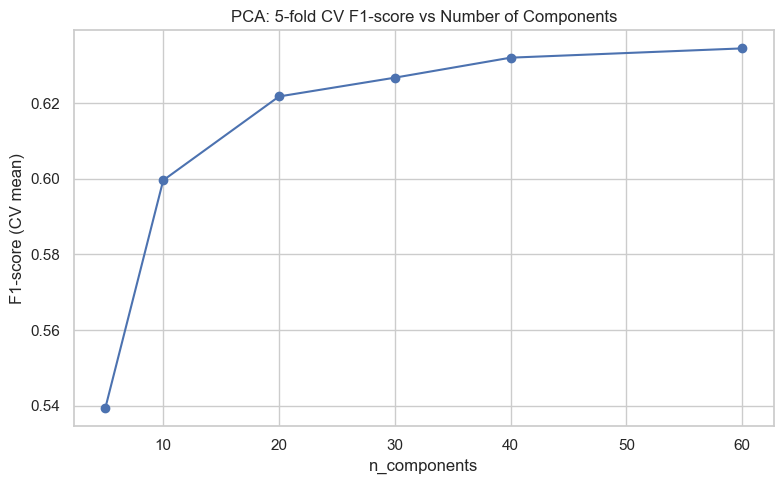

In [34]:
# PCA evaluation (dense one-hot for compatibility)
pca_rows = []

preprocessor_dense = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), fs_categorical_cols)
])

X_probe_dense = preprocessor_dense.fit_transform(X_fs)
max_comp = X_probe_dense.shape[1]

candidate_components = [5, 10, 20, 30, 40, 60]
k_pca_values = [k for k in candidate_components if k < max_comp]
if max_comp not in k_pca_values and max_comp <= 80:
    k_pca_values.append(max_comp)

for n_comp in k_pca_values:
    pca_pipe = Pipeline([
        ("prep", preprocessor_dense),
        ("pca", PCA(n_components=n_comp, random_state=42)),
        ("clf", base_clf)
    ])

    mean_f1, std_f1 = evaluate_pipeline_f1(pca_pipe, X_fs, y_fs)
    pca_rows.append({
        "method": "PCA",
        "n_components": n_comp,
        "cv_f1_mean": mean_f1,
        "cv_f1_std": std_f1
    })

pca_df = pd.DataFrame(pca_rows)
print("PCA CV results:")
display(pca_df)

plt.figure(figsize=(8, 5))
plt.plot(pca_df["n_components"], pca_df["cv_f1_mean"], marker="o")
plt.title("PCA: 5-fold CV F1-score vs Number of Components")
plt.xlabel("n_components")
plt.ylabel("F1-score (CV mean)")
plt.tight_layout()
plt.show()


**Phân tích kết quả (PCA):**
Nếu F1 giữ gần mức cao nhất ở số thành phần thấp, PCA đang nén thông tin hiệu quả và giảm nhiễu/đa cộng tuyến. Ngược lại, nếu F1 giảm rõ khi giảm số thành phần, dữ liệu có thể cần không gian chiều cao hơn để giữ ranh giới phân lớp. Kết quả này giúp chọn `n_components` phù hợp cho cân bằng giữa hiệu năng và tốc độ.

## 5.8 Dimensionality Reduction for Visualization: t-SNE
`t-SNE` là kỹ thuật phi tuyến cho trực quan hóa, tối ưu bảo toàn lân cận cục bộ khi ánh xạ dữ liệu từ không gian cao chiều xuống 2D/3D.

Hàm mục tiêu dựa trên độ lệch giữa phân phối xác suất cặp điểm ở không gian gốc và không gian nhúng (KL divergence):
$$
KL(P\|Q) = \sum_{i \ne j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
$$

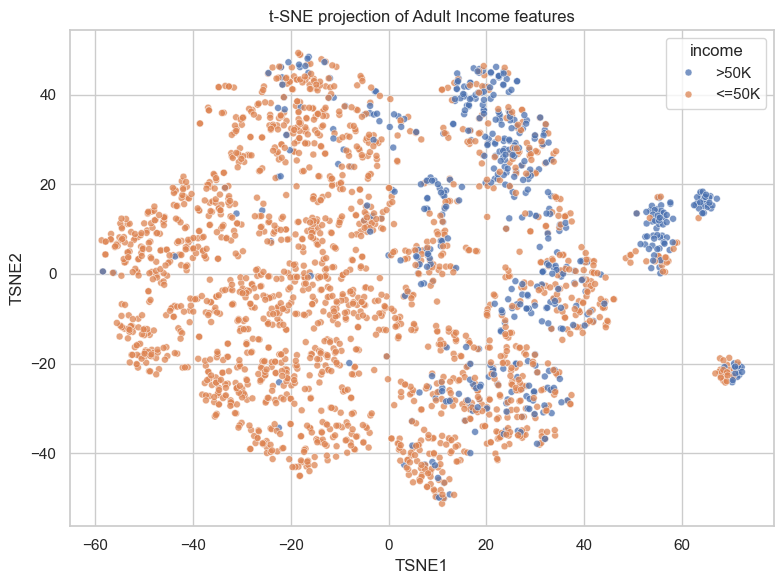

In [35]:
# t-SNE visualization on a manageable sample
viz_n = min(2500, len(X_fs))
X_viz = X_fs.iloc[:viz_n].copy()
y_viz = y_fs.iloc[:viz_n].copy()

# Dense transformed features then optional PCA pre-reduction for speed
X_viz_dense = preprocessor_dense.fit_transform(X_viz)

pca_for_tsne = PCA(n_components=min(30, X_viz_dense.shape[1]-1), random_state=42)
X_viz_pca = pca_for_tsne.fit_transform(X_viz_dense)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_tsne = tsne.fit_transform(X_viz_pca)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "income": y_viz.map({0: "<=50K", 1: ">50K"}).values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="income", s=25, alpha=0.75)
plt.title("t-SNE projection of Adult Income features")
plt.tight_layout()
plt.show()


**Phân tích kết quả (t-SNE):**
Biểu đồ t-SNE giúp quan sát mức tách cụm trực quan giữa hai lớp thu nhập. Nếu hai màu chồng lấn mạnh, bài toán có ranh giới phức tạp và mô hình tuyến tính có thể gặp khó khăn. Nếu xuất hiện các vùng tách tương đối rõ, điều đó gợi ý dữ liệu có cấu trúc hữu ích cho phân loại. Lưu ý t-SNE phục vụ trực quan hóa, không nên dùng trực tiếp như bước biến đổi đặc trưng chính cho mô hình dự báo cuối cùng.

## 5.9 UMAP (for larger datasets)
UMAP là kỹ thuật giảm chiều phi tuyến dựa trên học đa tạp, thường nhanh hơn t-SNE và giữ được cả cấu trúc cục bộ lẫn một phần cấu trúc toàn cục.

Ý tưởng chính: xây dựng đồ thị lân cận mờ trong không gian gốc, sau đó tối ưu biểu diễn chiều thấp để bảo toàn cấu trúc đồ thị này.

In [36]:
# UMAP visualization if the package is available
try:
    import umap

    umap_n = min(8000, len(X_fs))
    X_um = X_fs.iloc[:umap_n].copy()
    y_um = y_fs.iloc[:umap_n].copy()

    X_um_dense = preprocessor_dense.fit_transform(X_um)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )
    X_umap = reducer.fit_transform(X_um_dense)

    umap_df = pd.DataFrame({
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1],
        "income": y_um.map({0: "<=50K", 1: ">50K"}).values
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="income", s=18, alpha=0.7)
    plt.title("UMAP projection of Adult Income features")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("UMAP is skipped because the package is unavailable or failed to run.")
    print("Reason:", str(e))


UMAP is skipped because the package is unavailable or failed to run.
Reason: No module named 'umap'


**Phân tích kết quả (UMAP):**
Với tập dữ liệu tương đối lớn, UMAP thường cho thời gian chạy tốt hơn t-SNE và biểu đồ ổn định hơn khi thay đổi seed. Nếu cụm dữ liệu thể hiện ranh giới rõ hơn t-SNE, ta có thêm bằng chứng về cấu trúc manifold trong dữ liệu. Tuy nhiên tương tự t-SNE, UMAP chủ yếu dùng cho khám phá trực quan và hỗ trợ diễn giải.

# 6. Xử lý mất cân bằng lớp (SMOTE, ADASYN, Random Under-sampling).
## 6.1 Class Imbalance Handling: SMOTE
SMOTE sinh mẫu thiểu số mới bằng nội suy giữa một điểm thiểu số và các láng giềng gần:
$$
\mathbf{x}_{new} = \mathbf{x}_i + \lambda(\mathbf{x}_{nn}-\mathbf{x}_i),\quad \lambda\in(0,1)
$$
Mục tiêu là tăng đại diện lớp thiểu số và cải thiện Recall/F1-macro.

In [37]:
# Shared preprocessing for imbalance experiments (dense output for resampling methods)
imb_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fs_numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), fs_categorical_cols)
])

# We evaluate on untouched test set as required
strategies = {
    "Baseline (no resampling)": None,
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "RandomUnderSampler": RandomUnderSampler(random_state=42)
}

imb_rows = []
for name, sampler in strategies.items():
    steps = [("prep", imb_preprocessor)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("clf", LogisticRegression(max_iter=1500, solver="liblinear", random_state=42)))

    model = ImbPipeline(steps)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    imb_rows.append({
        "strategy": name,
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "auc_roc": roc_auc_score(y_test, y_prob)
    })

imbalance_df = pd.DataFrame(imb_rows).sort_values("f1_macro", ascending=False)
print("Evaluation on untouched test set:")
display(imbalance_df)


Evaluation on untouched test set:


,strategy,precision_macro,recall_macro,f1_macro,auc_roc
0,Baseline (no resampling),0.794292,0.741116,0.761890,0.897288
3,RandomUnderSampler,0.738286,0.818136,0.754844,0.897057
1,SMOTE,0.736706,0.813840,0.753580,0.895155
2,ADASYN,0.720175,0.807089,0.727981,0.891649


**Phân tích kết quả (SMOTE):**
So với baseline, SMOTE thường cải thiện Recall của lớp thiểu số và vì vậy có thể tăng F1-macro. Nếu Precision giảm nhẹ nhưng Recall tăng nhiều, đó là trade-off thường gặp và có thể chấp nhận tùy mục tiêu nghiệp vụ. Chỉ số AUC-ROC giúp kiểm tra thêm chất lượng xếp hạng xác suất thay vì chỉ dựa trên ngưỡng phân loại cố định.

## 6.2 Class Imbalance Handling: ADASYN
ADASYN mở rộng ý tưởng SMOTE bằng cách sinh nhiều mẫu hơn ở những vùng "khó học" (nơi lớp thiểu số bị bao quanh bởi lớp đa số). Nhờ đó mô hình được tập trung cải thiện ở các biên quyết định phức tạp.

In [38]:
# Show ADASYN-only row for focused interpretation
adasyn_row = imbalance_df[imbalance_df["strategy"] == "ADASYN"].copy()
print("ADASYN result:")
display(adasyn_row)


ADASYN result:


,strategy,precision_macro,recall_macro,f1_macro,auc_roc
2,ADASYN,0.720175,0.807089,0.727981,0.891649


**Phân tích kết quả (ADASYN):**
Nếu ADASYN tốt hơn SMOTE, dữ liệu nhiều khả năng có vùng biên phân lớp khó và không đồng đều. Ngược lại, nếu ADASYN kém hơn, có thể do việc sinh mẫu tập trung quá mức vào vùng nhiễu làm giảm độ chính xác tổng thể. Khi đó SMOTE hoặc chiến lược cân bằng đơn giản có thể ổn định hơn.

## 6.3 Class Imbalance Handling: Random Under-sampling
Random Under-sampling giảm ngẫu nhiên số mẫu lớp đa số để cân bằng tỷ lệ lớp. Ưu điểm là nhanh, đơn giản; nhược điểm là có thể làm mất thông tin quan trọng của lớp đa số.

In [39]:
# Show Random Under-sampling row for focused interpretation
rus_row = imbalance_df[imbalance_df["strategy"] == "RandomUnderSampler"].copy()
print("Random Under-sampling result:")
display(rus_row)


Random Under-sampling result:


,strategy,precision_macro,recall_macro,f1_macro,auc_roc
3,RandomUnderSampler,0.738286,0.818136,0.754844,0.897057


**Phân tích kết quả (Random Under-sampling):**
Nếu Recall tăng nhưng Precision hoặc AUC giảm đáng kể, nguyên nhân thường là mất thông tin từ lớp đa số sau khi cắt bớt dữ liệu. Phương pháp này phù hợp khi dữ liệu rất lớn hoặc cần huấn luyện nhanh, nhưng nên so sánh cẩn thận với các kỹ thuật over-sampling để tránh suy giảm hiệu năng tổng thể.

## 6.4 Vì sao không resampling trước khi chia train/test?
Nếu resampling được thực hiện **trước** khi tách train/test, các mẫu tổng hợp (hoặc mẫu giữ lại sau under-sampling) có thể làm rò rỉ thông tin thống kê từ toàn bộ dữ liệu sang tập test.

Hậu quả:
1. Đánh giá bị lạc quan giả tạo vì test không còn đại diện cho dữ liệu thực tế chưa thấy.
2. Mẫu tổng hợp có thể gián tiếp "gần" các điểm test, làm tăng điểm số không công bằng.
3. Quy trình triển khai thực tế bị sai lệch, vì production luôn cần dự đoán trên dữ liệu gốc chưa tái cân bằng.

Do đó, quy trình đúng là: **split train/test trước**, sau đó chỉ resample trên tập train.

In [40]:
# Build final preprocessed dataset and save to data/tabular-data/processed
df_final = df.copy()
df_final = df_final.replace("?", np.nan)

# Impute missing values
cat_cols_with_nan = ["workclass", "occupation", "native-country"]
df_final[cat_cols_with_nan] = imputer_mode.fit_transform(df_final[cat_cols_with_nan])
df_final[numeric_cols] = imputer_mice.fit_transform(df_final[numeric_cols])

# Remove outliers with Isolation Forest
iso_final = IsolationForest(contamination=0.05, random_state=42)
outlier_mask = iso_final.fit_predict(df_final[numeric_cols]) == 1
df_final = df_final.loc[outlier_mask].reset_index(drop=True)

# Scale numeric features
scaler_final = StandardScaler()
df_final[numeric_cols] = scaler_final.fit_transform(df_final[numeric_cols])

# Create target label for encoding
income_map = {"<=50K": 0, ">50K": 1, "<=50K.": 0, ">50K.": 1}
df_final["income_bin"] = df_final["income"].map(income_map)

# Target encoding with CV to avoid leakage

def target_encode_cv_frame(df_input, col, target_col, n_splits=5):
    df_res = pd.DataFrame(index=df_input.index)
    df_res[f"{col}_target"] = 0.0
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    global_mean = df_input[target_col].mean()
    for train_idx, val_idx in kf.split(df_input):
        mean_map = df_input.iloc[train_idx].groupby(col)[target_col].mean()
        df_res.loc[df_input.index[val_idx], f"{col}_target"] = df_input.iloc[val_idx][col].map(mean_map)
    df_res[f"{col}_target"] = df_res[f"{col}_target"].fillna(global_mean)
    return df_res

occ_target = target_encode_cv_frame(df_final, "occupation", "income_bin")
country_target = target_encode_cv_frame(df_final, "native-country", "income_bin")

# Ordinal encoding for education
edu_map = {
    "Preschool": 1,
    "1st-4th": 2,
    "5th-6th": 3,
    "7th-8th": 4,
    "9th": 5,
    "10th": 6,
    "11th": 7,
    "12th": 8,
    "HS-grad": 9,
    "Some-college": 10,
    "Assoc-voc": 11,
    "Assoc-acdm": 12,
    "Bachelors": 13,
    "Masters": 14,
    "Prof-school": 15,
    "Doctorate": 16,
}
df_final["education_ordinal"] = df_final["education"].map(edu_map)

# One-hot encoding for remaining low-cardinality features
low_card_cols = ["workclass", "marital-status", "relationship", "race", "sex"]
df_low_card = pd.get_dummies(df_final[low_card_cols], prefix=low_card_cols, drop_first=True)

# Use ordinal education and drop the redundant education-num
numeric_cols_final = [col for col in numeric_cols if col != "education-num"]

# Assemble processed dataset
processed_frames = [
    df_final[numeric_cols_final],
    df_final[["education_ordinal"]],
    occ_target,
    country_target,
    df_low_card,
    df_final[["income", "income_bin"]],
]

df_processed = pd.concat(processed_frames, axis=1)

output_dir = "../data/tabular-data/processed"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "adult_preprocessed.csv")
df_processed.to_csv(output_path, index=False)
print("Saved:", output_path)
print("Processed shape:", df_processed.shape)


Saved: ../data/tabular-data/processed\adult_preprocessed.csv
Processed shape: (46399, 33)
